In [7]:
import numpy as np
from lorenz63 import lorenz
from matplotlib import pyplot as plt

## Mathematical Description of `KoopmanEstimator`

This implementation builds a finite-dimensional approximation of the Koopman operator using EDMD (Extended Dynamic Mode Decomposition).

Given state snapshots $x_k \in \mathbb{R}^n$ and next-step snapshots $y_k \in \mathbb{R}^n$, it learns linear dynamics in a lifted observable space.

### 1. Observable (lifting) map

Choose a dictionary of observables $\psi: \mathbb{R}^n \to \mathbb{R}^m$ and define

$$
\psi(x) = [\psi_1(x), \ldots, \psi_m(x)]^\top.
$$

Supported dictionaries are:

- **Linear:** raw state (and optional bias term).
- **Polynomial:** monomials up to selected degree (plus optional state and bias).
- **RBF:** radial basis functions $\exp(-\gamma\|x-c_j\|^2)$ with learned centers $c_j$ (plus optional state and bias).

### 2. Lifted snapshot matrices

Form lifted data matrices

$$
\Psi_X =
\begin{bmatrix}
\psi(x_1)^\top \\
\vdots \\
\psi(x_N)^\top
\end{bmatrix},
\qquad
\Psi_Y =
\begin{bmatrix}
\psi(y_1)^\top \\
\vdots \\
\psi(y_N)^\top
\end{bmatrix}.
$$

If explicit $Y$ is not provided, the code uses consecutive pairs from one trajectory: $(x_k, y_k) = (X_k, X_{k+1})$.

### 3. Koopman operator fit (least squares / ridge)

It solves

$$
K = \arg\min_K \|\Psi_X K - \Psi_Y\|_F^2,
$$

or with Tikhonov regularization $\lambda = \texttt{reg}$:

$$
K = \arg\min_K \|\Psi_X K - \Psi_Y\|_F^2 + \lambda \|K\|_F^2.
$$

### 4. Decoder back to state space

A linear decoder is learned as

$$
B = \arg\min_B \|\Psi_X B - X\|_F^2,
$$

so a state estimate from observables is $\hat{x} = \psi(x) B$.

### 5. Prediction

Given initial state $x_0$, prediction proceeds in lifted space:

$$
\psi_{k+1} = \psi_k K,
\qquad
\hat{x}_{k+1} = \psi_{k+1} B.
$$

For $s$-step prediction:

$$
\hat{x}_{k+s} = \psi(x_k) K^s B.
$$

### 6. Reconstruction

Reconstruction returns the trajectory

$$
[x_0, \hat{x}_1, \hat{x}_2, \ldots, \hat{x}_T],
$$

using the same prediction recursion.

In [18]:
times = np.arange(0, 5, 0.001)
xstate, ystate, zstate = 1, 1, 1
rho, beta, sigma = 10, 8.0/3.0, 10.0   #spiral into one of two stable equilibria depending on initial conditions
# rho, beta, sigma = 28.0, 8.0/3.0, 10.0

out = lorenz(time_series=times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

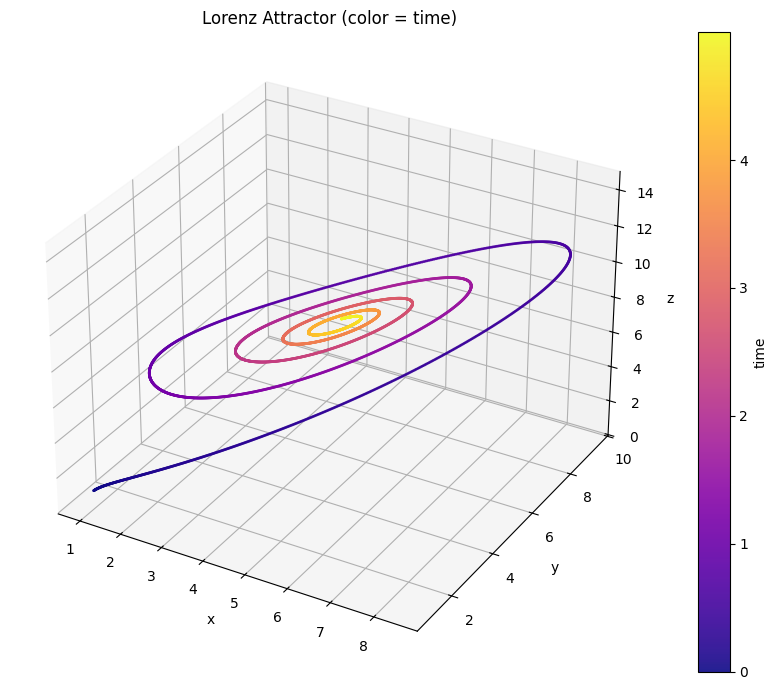

In [19]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


sc = ax.scatter(
    out[:, 0], out[:, 1], out[:, 2],
    c=times, cmap='plasma', s=1, alpha=0.9
)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, label="time")

plt.tight_layout()
plt.show()

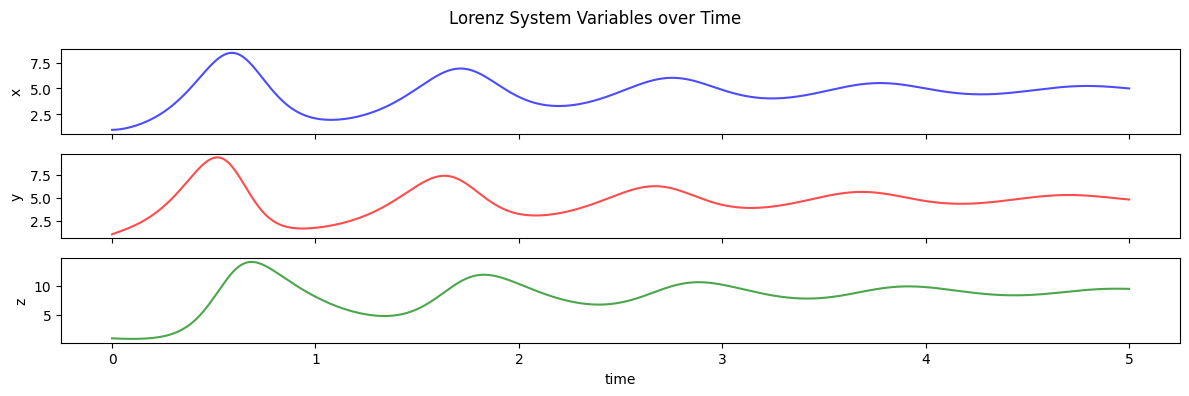

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

In [21]:
# Split the full state into train and test sets
train_size = int(0.8 * len(out))
state_train = out[1000:train_size]
state_test = out[train_size:]

t_train = times[1000:train_size]
t_test = times[train_size:]

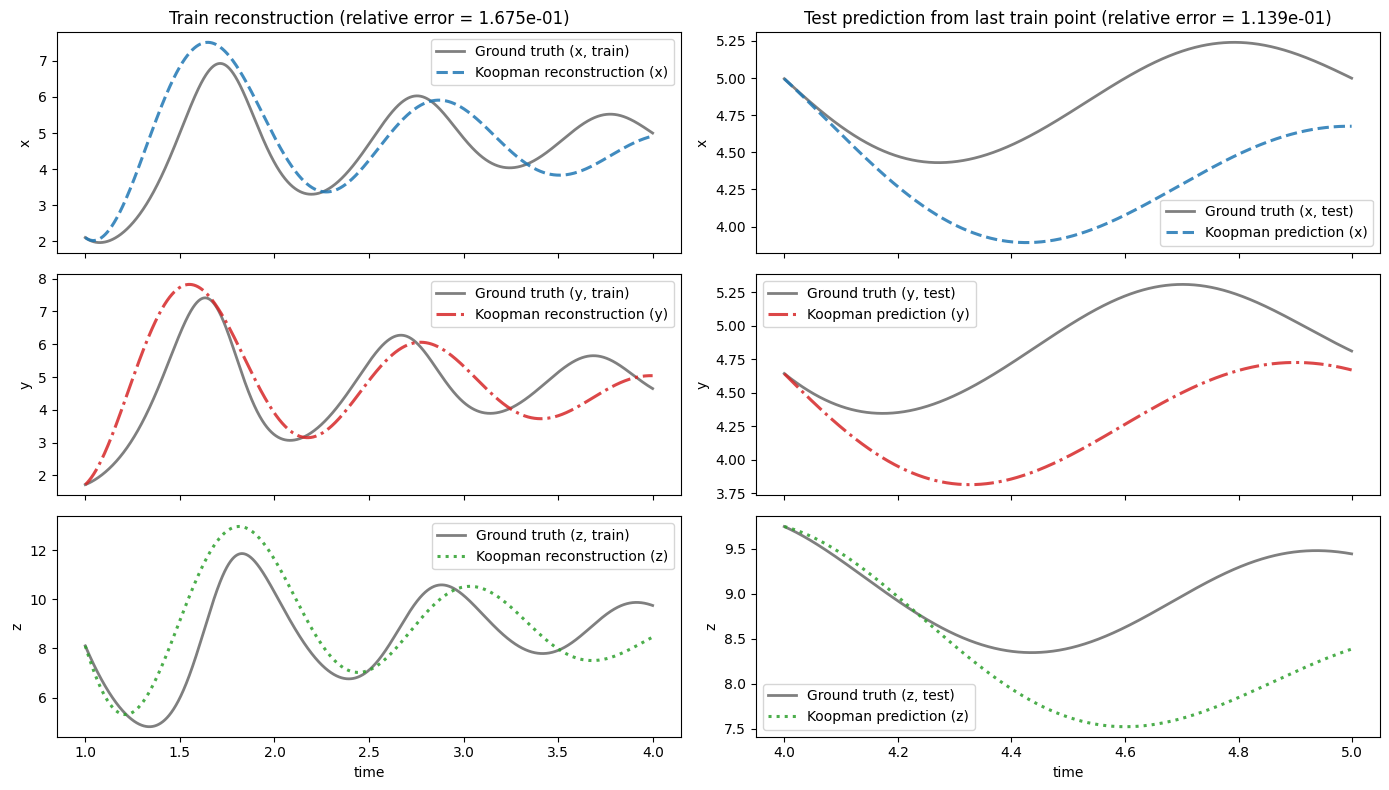

Estimated Koopman eigenvalues: [0.99938803+0.00511777j 0.99938803-0.00511777j 0.99993633+0.j        ]
Per-state train relative errors: {'x': np.float64(0.17725627372064115), 'y': np.float64(0.1912426377275346), 'z': np.float64(0.15583988677185434)}
Per-state test relative errors: {'x': np.float64(0.12876602256262357), 'y': np.float64(0.134942680947529), 'z': np.float64(0.10179363959905738)}


In [25]:
# Linear Koopman model on the full Lorenz state using KoopmanEstimator
from koopman import KoopmanEstimator


state_labels = ["x", "y", "z"]
state_colors = ["tab:blue", "tab:red", "tab:green"]
model_linestyles = ["--", "-.", ":"]

koop_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=1, # change this from 1, 2, to 3 to include higher-order monomials as observables
    include_bias=False,
    include_state=True,
    reg=1e-8,
    random_state=0,
)

# Fit on training trajectory (n_samples x n_states)
koop_model.fit(state_train)

# Training reconstruction (rollout from first training point)
state_train_rec = koop_model.reconstruct(state_train[0], n_steps=len(state_train) - 1)

# Test prediction (rollout from last training point)
state_test_pred = koop_model.predict(state_train[-1], steps=len(state_test))[0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(state_train_rec - state_train) / np.linalg.norm(state_train)
test_rel_err = np.linalg.norm(state_test_pred - state_test) / np.linalg.norm(state_test)
train_state_rel_err = np.linalg.norm(state_train_rec - state_train, axis=0) / np.linalg.norm(state_train, axis=0)
test_state_rel_err = np.linalg.norm(state_test_pred - state_test, axis=0) / np.linalg.norm(state_test, axis=0)

# Plots against ground truth
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex="col")

for idx, (label, color, linestyle) in enumerate(zip(state_labels, state_colors, model_linestyles)):
    axes[idx, 0].plot(
        t_train,
        state_train[:, idx],
        label=f"Ground truth ({label}, train)",
        color="black",
        linewidth=2.0,
        alpha=0.5,
        zorder=1,
    )
    axes[idx, 0].plot(
        t_train,
        state_train_rec[:, idx],
        label=f"Koopman reconstruction ({label})",
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
        alpha=0.85,
        zorder=2,
    )
    axes[idx, 0].set_ylabel(label)
    axes[idx, 0].legend()

    axes[idx, 1].plot(
        t_test,
        state_test[:, idx],
        label=f"Ground truth ({label}, test)",
        color="black",
        linewidth=2.0,
        alpha=0.5,
        zorder=1,
    )
    axes[idx, 1].plot(
        t_test,
        state_test_pred[:, idx],
        label=f"Koopman prediction ({label})",
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
        alpha=0.85,
        zorder=2,
    )
    axes[idx, 1].set_ylabel(label)
    axes[idx, 1].legend()

axes[0, 0].set_title(f"Train reconstruction (relative error = {train_rel_err:.3e})")
axes[0, 1].set_title(f"Test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[-1, 0].set_xlabel("time")
axes[-1, 1].set_xlabel("time")

plt.tight_layout()
plt.show()

K = np.real_if_close(np.linalg.eigvals(koop_model.K_))
print("Estimated Koopman eigenvalues:", K[: min(5, len(K))])
print("Per-state train relative errors:", dict(zip(state_labels, train_state_rel_err)))
print("Per-state test relative errors:", dict(zip(state_labels, test_state_rel_err)))

A matrix:
[[ 9.89950169e-01 -2.00075193e-02  1.43365464e-02]
 [ 1.00247918e-02  1.01497569e+00 -2.74811334e-03]
 [ 1.33523084e-05  2.68328576e-03  9.93786539e-01]]

Discrete-time eigenvalues:
[0.99993633+0.j         0.99938803-0.00511777j 0.99938803+0.00511777j]

Continuous-time eigenvalues:
[-0.06366923+0.j         -0.59904198-5.12085443j -0.59904198+5.12085443j]

Observable dimension: 3
State dimension: 3

Mode 1: lambda = 0.999936+0j
  dynamic mode = [4.09231059 4.06625531 7.7230349 ]
Mode 2: lambda = 0.999388-0.00511777j
  dynamic mode = [2.55214729-0.90865885j 1.93395264-2.16114257j 3.67315443+2.09058093j]
Mode 3: lambda = 0.999388+0.00511777j
  dynamic mode = [2.55214729+0.90865885j 1.93395264+2.16114257j 3.67315443-2.09058093j]


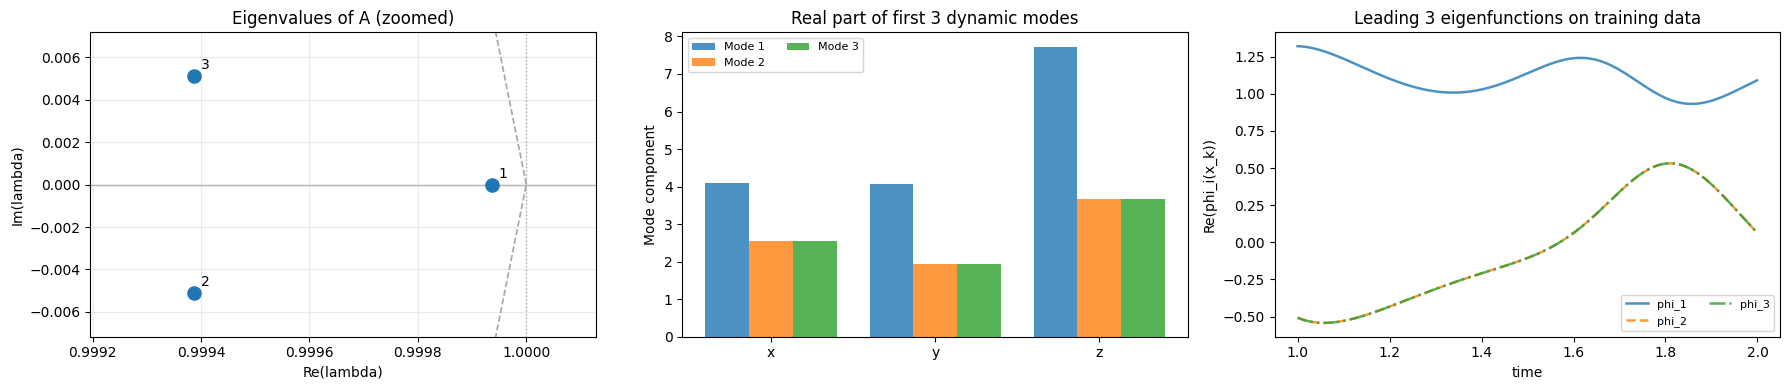

In [26]:
# Spectral analysis of A = koop_model.K_ via eigenvalues, dynamic modes, and eigenfunctions
A = koop_model.K_
eigvals, eigvecs_right = np.linalg.eig(A)
sort_idx = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_idx]
eigvecs_right = eigvecs_right[:, sort_idx]

# For psi_{k+1} = psi_k A, Koopman eigenfunctions are phi_j(x) = psi(x) v_j
psi_train = koop_model._lift(state_train)
eigenfunction_values = psi_train @ eigvecs_right

# State reconstruction x = psi B = Phi M, where M = V^{-1} B
modal_decoder = np.linalg.solve(eigvecs_right, koop_model.B_)
dynamic_modes = modal_decoder.T
continuous_eigvals = np.log(eigvals) / (times[1] - times[0])
n_modes_plot = min(6, eigvals.shape[0])

print("A matrix:")
print(np.real_if_close(A))
print()
print("Discrete-time eigenvalues:")
print(np.real_if_close(eigvals))
print()
print("Continuous-time eigenvalues:")
print(np.real_if_close(continuous_eigvals))
print()
print(f"Observable dimension: {A.shape[0]}")
print(f"State dimension: {dynamic_modes.shape[0]}")
print()
for mode_idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    mode = dynamic_modes[:, mode_idx - 1]
    print(f"Mode {mode_idx}: lambda = {lam:.6g}")
    print("  dynamic mode =", np.real_if_close(mode))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Eigenvalues in the complex plane
axes[0].scatter(eigvals.real, eigvals.imag, color="tab:blue", s=90, zorder=3)
for idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    axes[0].annotate(f"{idx}", (lam.real, lam.imag), textcoords="offset points", xytext=(5, 5))
unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
axes[0].plot(unit_circle.real, unit_circle.imag, "k--", alpha=0.35, linewidth=1.2)
axes[0].axhline(0.0, color="0.7", linewidth=1)
axes[0].axvline(1.0, color="0.7", linewidth=1, linestyle=":")
real_pad = max(1e-4, 0.35 * np.ptp(eigvals.real))
imag_pad = max(5e-4, 0.2 * np.ptp(eigvals.imag))
axes[0].set_xlim(eigvals.real.min() - real_pad, eigvals.real.max() + real_pad)
axes[0].set_ylim(eigvals.imag.min() - imag_pad, eigvals.imag.max() + imag_pad)
axes[0].grid(alpha=0.25)
axes[0].set_title("Eigenvalues of A (zoomed)")
axes[0].set_xlabel("Re(lambda)")
axes[0].set_ylabel("Im(lambda)")
axes[0].set_aspect("auto")

# Real part of leading dynamic modes in state coordinates
mode_positions = np.arange(len(state_labels))
bar_width = 0.8 / n_modes_plot
for idx in range(n_modes_plot):
    axes[1].bar(
        mode_positions + idx * bar_width,
        np.real(dynamic_modes[:, idx]),
        width=bar_width,
        label=f"Mode {idx + 1}",
        alpha=0.8,
    )
axes[1].set_xticks(mode_positions + 0.4 - bar_width / 2)
axes[1].set_xticklabels(state_labels)
axes[1].set_title(f"Real part of first {n_modes_plot} dynamic modes")
axes[1].set_ylabel("Mode component")
axes[1].legend(ncol=2, fontsize=8)

# Leading eigenfunction coordinates along the training trajectory
n_plot = min(1000, len(t_train))
eigenfunction_styles = ["-", "--", "-.", ":"]
for idx in range(n_modes_plot):
    axes[2].plot(
        t_train[:n_plot],
        np.real(eigenfunction_values[:n_plot, idx]),
        label=f"phi_{idx + 1}",
        linestyle=eigenfunction_styles[idx % len(eigenfunction_styles)],
        linewidth=1.8,
        alpha=0.8,
    )
axes[2].set_title(f"Leading {n_modes_plot} eigenfunctions on training data")
axes[2].set_xlabel("time")
axes[2].set_ylabel("Re(phi_i(x_k))")
axes[2].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

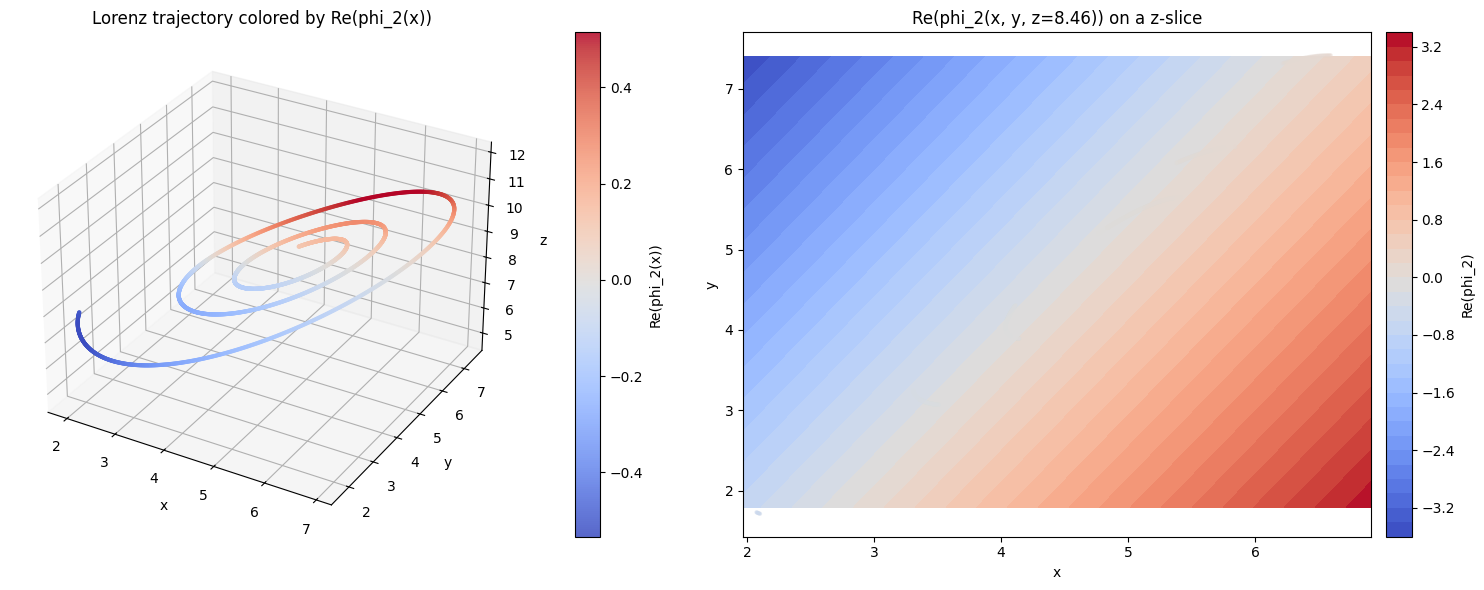

In [28]:
# State-space views of one Koopman eigenfunction
mode_scores = np.std(np.real(eigenfunction_values[:, :n_modes_plot]), axis=0)
mode_to_plot = int(np.argmax(mode_scores))
phi_label = f"phi_{mode_to_plot + 1}"
phi_train = np.real(eigenfunction_values[:, mode_to_plot])

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2)

# 3D trajectory colored by the selected eigenfunction value
sample_stride = max(1, len(state_train) // 5000)
state_plot = state_train[::sample_stride]
phi_plot = phi_train[::sample_stride]
sc = ax1.scatter(
    state_plot[:, 0],
    state_plot[:, 1],
    state_plot[:, 2],
    c=phi_plot,
    cmap="coolwarm",
    s=4,
    alpha=0.85,
    rasterized=True,
    vmin=np.quantile(phi_train, 0.02),
    vmax=np.quantile(phi_train, 0.98),
)
ax1.set_title(f"Lorenz trajectory colored by Re({phi_label}(x))")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
fig.colorbar(sc, ax=ax1, pad=0.08, label=f"Re({phi_label}(x))")

# 2D slice of the same eigenfunction at a fixed z level
grid_size = 160
x_min, x_max = np.quantile(state_train[:, 0], [0.01, 0.99])
y_min, y_max = np.quantile(state_train[:, 1], [0.01, 0.99])
z_slice = float(np.median(state_train[:, 2])) # choose a z value near the middle of the training data for the slice
x_grid = np.linspace(x_min, x_max, grid_size)
y_grid = np.linspace(y_min, y_max, grid_size)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
slice_states = np.column_stack([
    X_grid.ravel(),
    Y_grid.ravel(),
    np.full(X_grid.size, z_slice),
])
psi_slice = koop_model._lift(slice_states)
phi_slice = np.real((psi_slice @ eigvecs_right)[:, mode_to_plot]).reshape(X_grid.shape)

contours = ax2.contourf(
    X_grid,
    Y_grid,
    phi_slice,
    levels=40,
    cmap="coolwarm",
)
near_slice = np.abs(state_train[:, 2] - z_slice) < 0.5
ax2.scatter(
    state_train[near_slice, 0],
    state_train[near_slice, 1],
    c=phi_train[near_slice],
    cmap="coolwarm",
    s=4,
    alpha=0.35,
    vmin=np.min(phi_slice),
    vmax=np.max(phi_slice),
)
ax2.set_title(f"Re({phi_label}(x, y, z={z_slice:.2f})) on a z-slice")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
fig.colorbar(contours, ax=ax2, pad=0.02, label=f"Re({phi_label})")

plt.tight_layout()
plt.show()